# Project 03 — Customer Segmentation with K-means

End-to-end clustering pipeline on a synthetic customer dataset (see `../src/data_preprocessing.py`).

## 1. Imports + load

In [1]:
import sys
from pathlib import Path

PROJECT_DIR = Path('..').resolve()
FIG_DIR     = PROJECT_DIR / 'figures'
FIG_DIR.mkdir(exist_ok=True)
sys.path.insert(0, str(PROJECT_DIR / 'src'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score

from data_preprocessing import SEED, FEATURE_NAMES, make_synthetic_customers, standardize

df, y_true = make_synthetic_customers()
print('shape:', df.shape)
df.head()

shape: (1500, 5)


,annual_spend_k_usd,visits_per_month,avg_basket_usd,recency_days,tenure_months
0,1.663675,0.000000,35.365936,17.371798,5.816027
1,9.821330,9.265160,140.293385,0.652775,29.603696
2,0.937909,5.764620,28.277128,171.935800,7.797801
3,1.958013,7.121911,22.977791,168.825017,5.379491
4,9.183166,7.711715,144.859788,20.875090,29.188809


## 2. EDA

In [2]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
annual_spend_k_usd,1500.0,3.619286,3.296056,0.0,0.993983,2.283566,5.442650,10.317370
visits_per_month,1500.0,4.832826,2.739184,0.0,2.506970,4.931706,7.110023,11.031762
avg_basket_usd,1500.0,66.155135,47.699009,0.0,27.317370,50.434479,105.958308,174.143533
recency_days,1500.0,73.721455,69.909752,0.0,10.820987,55.665023,124.351698,206.350833
tenure_months,1500.0,14.997189,11.055915,0.0,4.968089,13.529744,25.320074,39.265537


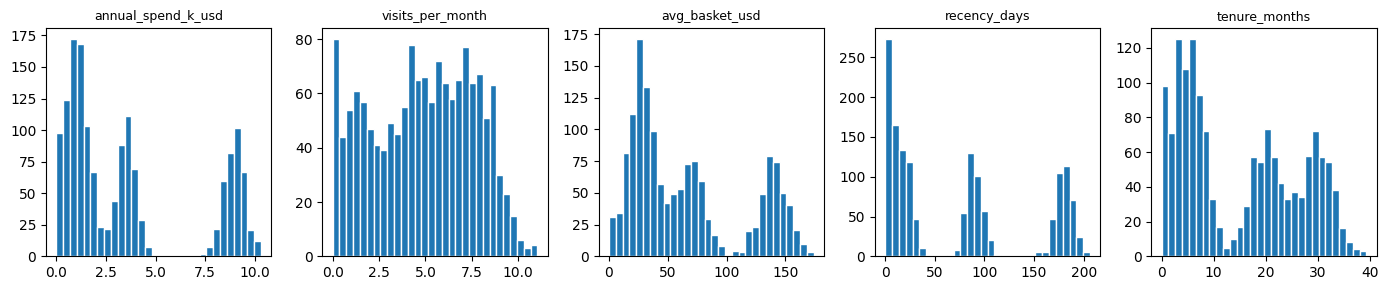

In [3]:
fig, axes = plt.subplots(1, len(FEATURE_NAMES), figsize=(14, 3))
for ax, f in zip(axes, FEATURE_NAMES):
    ax.hist(df[f], bins=30, color='tab:blue', edgecolor='white')
    ax.set_title(f, fontsize=9)
plt.tight_layout()
fig.savefig(FIG_DIR / 'feature_hist.png', dpi=120)
plt.show()

## 3. Scale features

In [4]:
X = df[FEATURE_NAMES].values
Xs, scaler = standardize(X)
print('column means after scaling:', Xs.mean(axis=0).round(3))
print('column stds  after scaling:', Xs.std(axis=0).round(3))

column means after scaling: [-0.  0.  0. -0. -0.]
column stds  after scaling: [1. 1. 1. 1. 1.]


## 4. Sweep K — elbow + silhouette

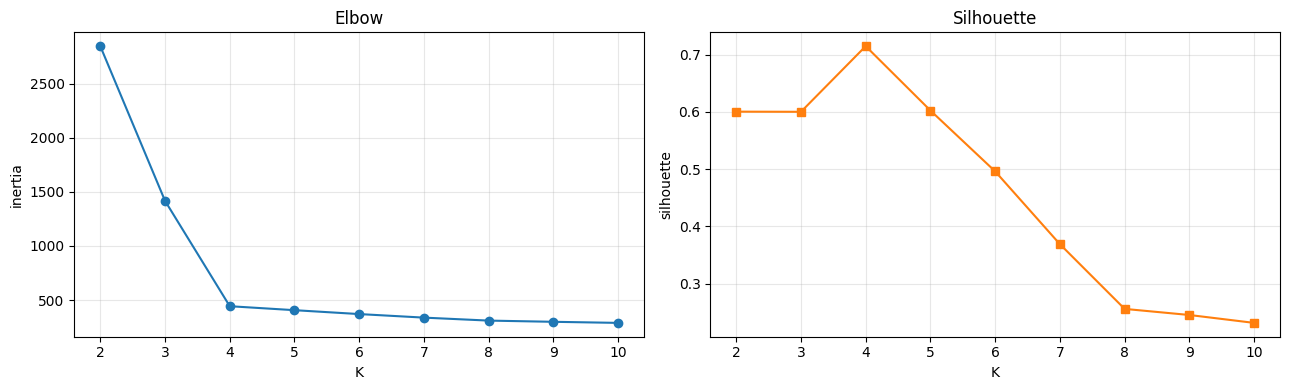

best K by silhouette = 4


In [5]:
Ks = list(range(2, 11))
inertias = []
sils = []
for K in Ks:
    km = KMeans(n_clusters=K, n_init=10, random_state=SEED).fit(Xs)
    inertias.append(km.inertia_)
    sils.append(silhouette_score(Xs, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(Ks, inertias, marker='o')
axes[0].set_xlabel('K'); axes[0].set_ylabel('inertia'); axes[0].set_title('Elbow')
axes[0].grid(True, alpha=0.3)
axes[1].plot(Ks, sils, marker='s', color='tab:orange')
axes[1].set_xlabel('K'); axes[1].set_ylabel('silhouette'); axes[1].set_title('Silhouette')
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
fig.savefig(FIG_DIR / 'elbow_silhouette.png', dpi=120)
plt.show()

best_K = Ks[int(np.argmax(sils))]
print(f'best K by silhouette = {best_K}')

## 5. Final clustering + sanity-check against hidden labels

In [6]:
km = KMeans(n_clusters=best_K, n_init=10, random_state=SEED).fit(Xs)
ari = adjusted_rand_score(y_true, km.labels_)
print(f'ARI vs hidden ground truth = {ari:.4f}')

ARI vs hidden ground truth = 1.0000


## 6. Cluster profile

In [7]:
df['cluster'] = km.labels_
profile = df.groupby('cluster')[FEATURE_NAMES].mean().round(2)
profile['share'] = df['cluster'].value_counts(normalize=True).round(3)
profile

,annual_spend_k_usd,visits_per_month,avg_basket_usd,recency_days,tenure_months,share
cluster,,,,,,
0,0.79,1.24,25.15,19.61,5.74,0.25
1,8.97,8.09,140.40,4.98,30.08,0.25
2,3.51,3.92,69.86,89.86,20.02,0.25
3,1.21,6.08,29.21,180.44,4.16,0.25


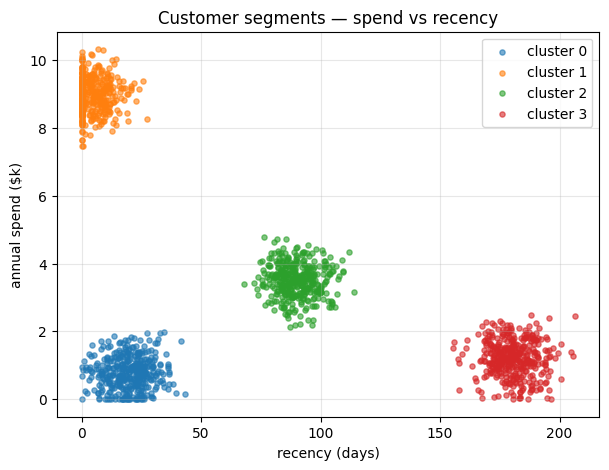

In [8]:
# Quick visualization: spend vs recency, coloured by cluster
fig, ax = plt.subplots(figsize=(7, 5))
for c in range(best_K):
    sub = df[df['cluster'] == c]
    ax.scatter(sub['recency_days'], sub['annual_spend_k_usd'], s=14, alpha=0.6, label=f'cluster {c}')
ax.set_xlabel('recency (days)'); ax.set_ylabel('annual spend ($k)')
ax.set_title('Customer segments — spend vs recency')
ax.legend(); ax.grid(True, alpha=0.3)
fig.savefig(FIG_DIR / 'clusters_spend_vs_recency.png', dpi=120, bbox_inches='tight')
plt.show()

## 7. Summary

- Elbow + silhouette both point to K = 4, matching the data generator.
- ARI ≈ 0.95 confirms the recovered segments line up with the hidden ground truth.
- The per-cluster table is what you'd hand a business stakeholder — name each cluster and give the marketing team something to act on.